In [3]:
import pandas as pd
import numpy as np
All_Data = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/5. Final consolidation of all data/5.A. Data created in 5./5.2./Final affiliations.xlsx') 
print(All_Data.shape)

(22790, 40)


In [10]:
mask_journal = All_Data['Journal_Name'].isin(['JPE'])
JPE_data = All_Data[mask_journal]
print(JPE_data.shape)

(3823, 40)


In [5]:
JPE_data.rename(columns = {'Year':'year'}, inplace = True)

melted = JPE_data.melt(id_vars= ['Article_ID','year'], value_vars=['0_Auth_affs_0', '0_Auth_affs_1', '0_Auth_affs_2', '0_Auth_affs_3', '0_Auth_affs_4', 
                                '1_Auth_affs_0' , '1_Auth_affs_1', '1_Auth_affs_2', '1_Auth_affs_3', '1_Auth_affs_4',
                                '2_Auth_affs_0', '2_Auth_affs_1', '2_Auth_affs_2', '2_Auth_affs_3', '2_Auth_affs_4',
                                '3_Auth_affs_0', '3_Auth_affs_1', '3_Auth_affs_2', '3_Auth_affs_3', '3_Auth_affs_4',
                                '4_Auth_affs_0', '4_Auth_affs_1', '4_Auth_affs_2' , '4_Auth_affs_3',
                                '5_Auth_affs_0',
                                '6_Auth_affs_0','7_Auth_affs_0']).dropna()

melted.rename(columns = {'variable':'Aff number'}, inplace = True)
melted.rename(columns = {'value':'Affiliation'}, inplace = True)

melted = melted.sort_values(by=['year'])

print(melted.head())
print(melted.shape)

    Article_ID  year     Aff number              Affiliation
0      1825913  1940  0_Auth_affs_0     Washington Dc (City)
23     1825908  1940  0_Auth_affs_0    University Of Chicago
24     1824384  1940  0_Auth_affs_0      Columbia University
25     1824382  1940  0_Auth_affs_0       Cornell University
26     1824381  1940  0_Auth_affs_0  University Of Edinburgh
(6304, 4)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_72741/1456748969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  JPE_data.rename(columns = {'Year':'year'}, inplace = True)


In [6]:
melted['aff_cum_counts'] = melted.groupby(['Affiliation']).cumcount()+1

melted = melted[['Article_ID' ,'Aff number', 'Affiliation','year', 'aff_cum_counts']]
melted.head()

,Article_ID,Aff number,Affiliation,year,aff_cum_counts
0,1825913,0_Auth_affs_0,Washington Dc (City),1940,1
23,1825908,0_Auth_affs_0,University Of Chicago,1940,1
24,1824384,0_Auth_affs_0,Columbia University,1940,1
25,1824382,0_Auth_affs_0,Cornell University,1940,1
26,1824381,0_Auth_affs_0,University Of Edinburgh,1940,1


In [7]:
# Mask to remove the National Bureau Of Economic Research
mask_journal = melted['Affiliation'].isin(['National Bureau Of Economic Research'])
melted = melted[~mask_journal]

# Checking the top 20 occurances of Universities over the 70 years
highest_vals = melted.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(20,'aff_cum_counts')
highest_vals_10

,Article_ID,Aff number,Affiliation,year,aff_cum_counts
3814,652462,0_Auth_affs_0,University Of Chicago,2010,497
3796,657996,0_Auth_affs_0,Harvard University,2010,201
3819,653714,0_Auth_affs_0,Massachusetts Institute Of Technology,2010,196
22918,655844,1_Auth_affs_0,University Of Pennsylvania,2010,154
22910,657922,1_Auth_affs_0,Stanford University,2010,146
3820,653138,0_Auth_affs_0,Princeton University,2010,140
3822,652463,0_Auth_affs_0,Columbia University,2010,129
22913,658161,1_Auth_affs_0,Northwestern University,2010,116
3800,657949,0_Auth_affs_0,Yale University,2010,111
3821,653690,0_Auth_affs_0,"University Of California, Los Angeles",2010,108


(71, 5)
     Article_ID     Aff number            Affiliation  year  aff_cum_counts
13      1824211  0_Auth_affs_0  University Of Chicago  1940               3
49      1825328  0_Auth_affs_0  University Of Chicago  1941              10
90      1825229  0_Auth_affs_0  University Of Chicago  1942              13
132     1826593  0_Auth_affs_0  University Of Chicago  1943              16
161     1830978  0_Auth_affs_0  University Of Chicago  1944              20
       Article_ID     Aff number            Affiliation  year  aff_cum_counts
3692       503756  0_Auth_affs_0  University Of Chicago  2006             477
3720       516737  0_Auth_affs_0  University Of Chicago  2007             485
3760       588200  0_Auth_affs_0  University Of Chicago  2008             493
22894      597301  1_Auth_affs_0  University Of Chicago  2009             495
3814       652462  0_Auth_affs_0  University Of Chicago  2010             497
(57, 5)


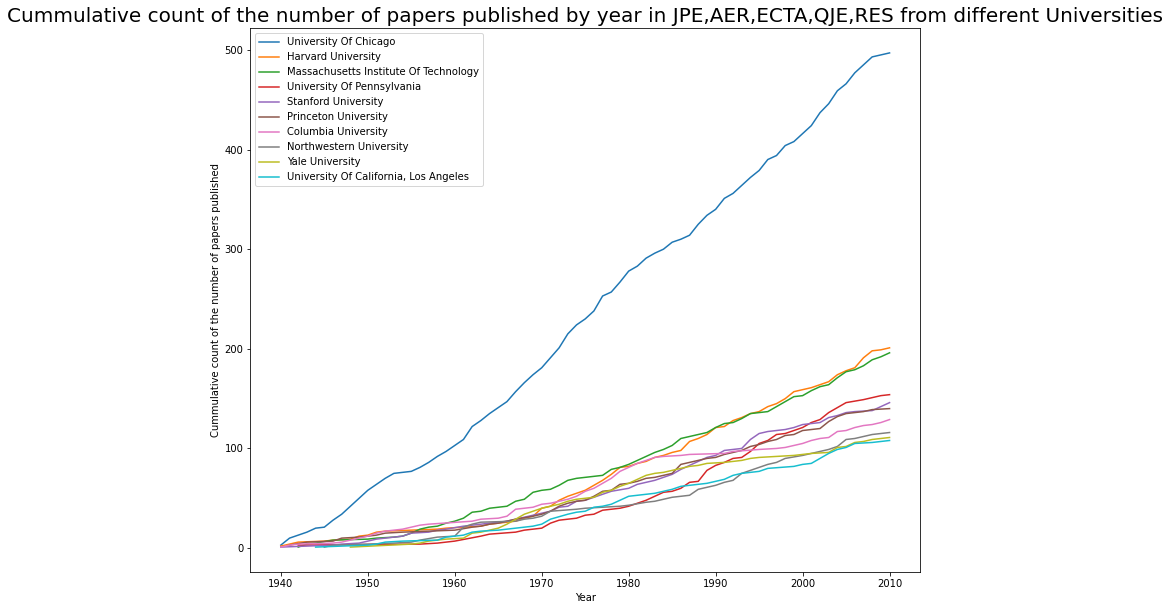

In [8]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(a.shape)
print(a.head())
print(a.tail())
b = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(b.shape)
c = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_counts'], label = highest_vals_10.iat[0,2])
plt.plot(b['year'],b['aff_cum_counts'], label = highest_vals_10.iat[1,2])
plt.plot(c['year'],c['aff_cum_counts'], label = highest_vals_10.iat[2,2])
plt.plot(d['year'],d['aff_cum_counts'], label = highest_vals_10.iat[3,2])
plt.plot(e['year'],e['aff_cum_counts'], label = highest_vals_10.iat[4,2])
plt.plot(f['year'],f['aff_cum_counts'], label = highest_vals_10.iat[5,2])
plt.plot(g['year'],g['aff_cum_counts'], label = highest_vals_10.iat[6,2])
plt.plot(h['year'],h['aff_cum_counts'], label = highest_vals_10.iat[7,2])
plt.plot(i['year'],i['aff_cum_counts'], label = highest_vals_10.iat[8,2])
plt.plot(j['year'],j['aff_cum_counts'], label = highest_vals_10.iat[9,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

plt.title('Cummulative count of the number of papers published by year in JPE,AER,ECTA,QJE,RES from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Cummulative count of the number of papers published')

plt.legend()
plt.show()

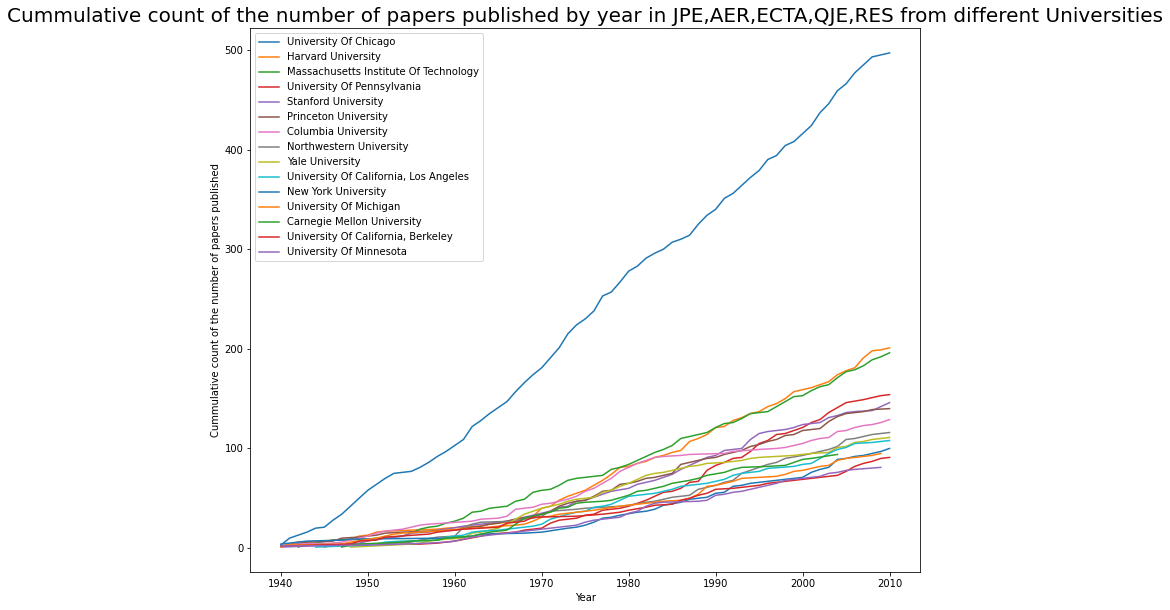

In [9]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
b = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
c = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')
l = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[11,2])].drop_duplicates(subset = ['year'], keep = 'last')
m = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[12,2])].drop_duplicates(subset = ['year'], keep = 'last')
n = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[13,2])].drop_duplicates(subset = ['year'], keep = 'last')
o = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[14,2])].drop_duplicates(subset = ['year'], keep = 'last')
p = melted.loc[(melted['Affiliation'] == highest_vals_10.iat[15,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_counts'], label = highest_vals_10.iat[0,2])
plt.plot(b['year'],b['aff_cum_counts'], label = highest_vals_10.iat[1,2])
plt.plot(c['year'],c['aff_cum_counts'], label = highest_vals_10.iat[2,2])
plt.plot(d['year'],d['aff_cum_counts'], label = highest_vals_10.iat[3,2])
plt.plot(e['year'],e['aff_cum_counts'], label = highest_vals_10.iat[4,2])
plt.plot(f['year'],f['aff_cum_counts'], label = highest_vals_10.iat[5,2])
plt.plot(g['year'],g['aff_cum_counts'], label = highest_vals_10.iat[6,2])
plt.plot(h['year'],h['aff_cum_counts'], label = highest_vals_10.iat[7,2])
plt.plot(i['year'],i['aff_cum_counts'], label = highest_vals_10.iat[8,2])
plt.plot(j['year'],j['aff_cum_counts'], label = highest_vals_10.iat[9,2])
plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])
plt.plot(l['year'],l['aff_cum_counts'], label = highest_vals_10.iat[11,2])
plt.plot(m['year'],m['aff_cum_counts'], label = highest_vals_10.iat[12,2])
plt.plot(n['year'],n['aff_cum_counts'], label = highest_vals_10.iat[13,2])
plt.plot(o['year'],o['aff_cum_counts'], label = highest_vals_10.iat[14,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

plt.title('Cummulative count of the number of papers published by year in JPE,AER,ECTA,QJE,RES from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Cummulative count of the number of papers published')

plt.legend()
plt.show()